In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

DATASET_PATH = "spambase_csv.xls"

df = pd.read_csv(DATASET_PATH)

print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

df.head()

Dataset Shape: (4601, 58)

Column Names:
['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet', 'word_freq_order', 'word_freq_mail', 'word_freq_receive', 'word_freq_will', 'word_freq_people', 'word_freq_report', 'word_freq_addresses', 'word_freq_free', 'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology', 'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct', 'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project', 'word_freq_re', 'word_freq_edu', 'word_freq_table', 'word_freq_conference', 'char_freq_%3B', 'char_freq_%28', 'char_freq_%5B', 'char

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [33]:
print("Missing values in each column:")
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values in each column:
word_freq_make                0
word_freq_address             0
word_freq_all                 0
word_freq_3d                  0
word_freq_our                 0
word_freq_over                0
word_freq_remove              0
word_freq_internet            0
word_freq_order               0
word_freq_mail                0
word_freq_receive             0
word_freq_will                0
word_freq_people              0
word_freq_report              0
word_freq_addresses           0
word_freq_free                0
word_freq_business            0
word_freq_email               0
word_freq_you                 0
word_freq_credit              0
word_freq_your                0
word_freq_font                0
word_freq_000                 0
word_freq_money               0
word_freq_hp                  0
word_freq_hpl                 0
word_freq_george              0
word_freq_650                 0
word_freq_lab                 0
word_freq_labs                0
word_freq

In [34]:
target_column = df.columns[-1]

print("Target column:", target_column)

X = df.drop(columns=[target_column])
y = df[target_column]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget values:")
print(y.value_counts())

Target column: class
Feature shape: (4601, 57)
Target shape: (4601,)

Target values:
class
0    2788
1    1813
Name: count, dtype: int64


In [35]:
if y.dtype == "object":
    print("Original target values:", y.unique())
    y = y.astype(str).str.lower().map({"ham": 0, "spam": 1})

    if y.isnull().any():
        raise ValueError("Target contains values other than ham/spam. Check the target column.")
else:
    # Ensure the target is numeric.
    y = pd.to_numeric(y)

print("Final target values:")
print(y.value_counts())

Final target values:
class
0    2788
1    1813
Name: count, dtype: int64


In [36]:
print("Statistical Summary:")
display(df.describe())

Statistical Summary:


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
count,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,...,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000
mean,0.104553,0.213015,0.280656,0.065425,0.312223,0.095901,0.114208,0.105295,0.090067,0.239413,...,0.038575,0.139030,0.016976,0.269071,0.075811,0.044238,5.191515,52.172789,283.289285,0.394045
std,0.305358,1.290575,0.504143,1.395151,0.672513,0.273824,0.391441,0.401071,0.278616,0.644755,...,0.243471,0.270355,0.109394,0.815672,0.245882,0.429342,31.729449,194.891310,606.347851,0.488698
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.588000,6.000000,35.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.065000,0.000000,0.000000,0.000000,0.000000,2.276000,15.000000,95.000000,0.000000
75%,0.000000,0.000000,0.420000,0.000000,0.380000,0.000000,0.000000,0.000000,0.000000,0.160000,...,0.000000,0.188000,0.000000,0.315000,0.052000,0.000000,3.706000,43.000000,266.000000,1.000000
max,4.540000,14.280000,5.100000,42.810000,10.000000,5.880000,7.270000,11.110000,5.260000,18.180000,...,4.385000,9.752000,4.081000,32.478000,6.003000,19.829000,1102.500000,9989.000000,15841.000000,1.000000


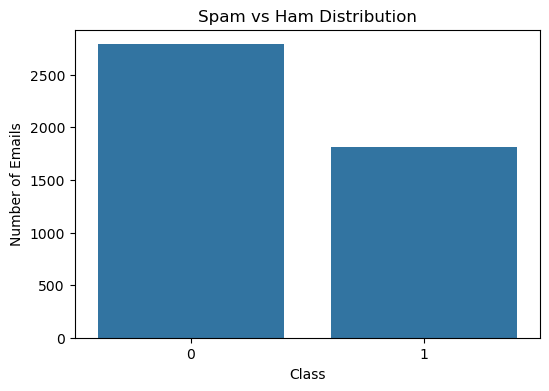

In [37]:
plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title("Spam vs Ham Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Emails")
plt.show()

In [38]:
class_counts = y.value_counts()

print("Class Distribution:")
print(class_counts)

print("\nClass Percentage:")
print((class_counts / len(y) * 100).round(2))

Class Distribution:
class
0    2788
1    1813
Name: count, dtype: int64

Class Percentage:
class
0    60.6
1    39.4
Name: count, dtype: float64


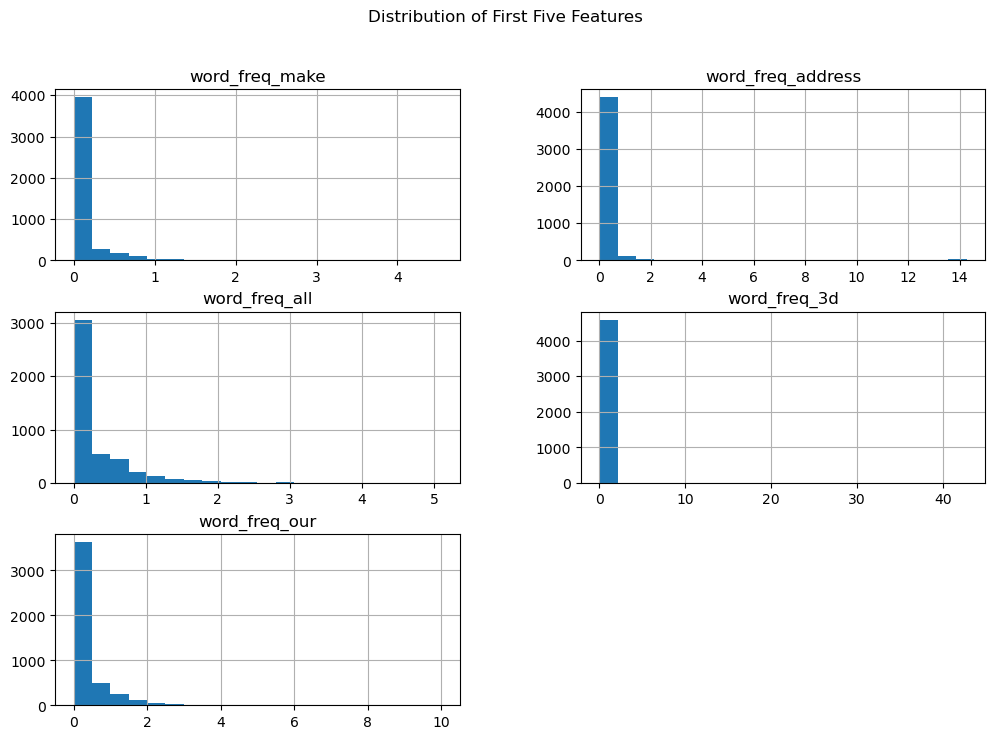

In [39]:
X.iloc[:, :5].hist(figsize=(12, 8), bins=20)
plt.suptitle("Distribution of First Five Features")
plt.show()

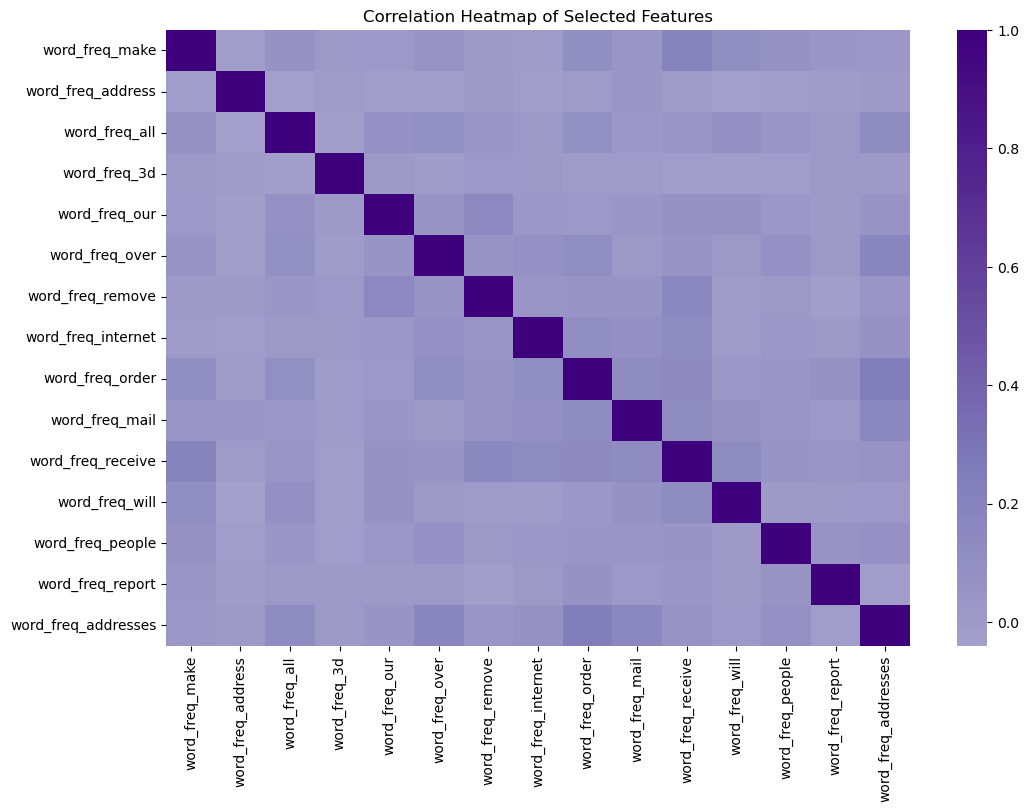

In [40]:
plt.figure(figsize=(12, 8))
correlation = X.iloc[:, :15].corr()
sns.heatmap(correlation, cmap="Purples", center=0)
plt.title("Correlation Heatmap of Selected Features")
plt.show()

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (3680, 57)
Testing data: (921, 57)


In [42]:
baseline_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000))
])

start_time = time.time()
baseline_lr.fit(X_train, y_train)
lr_training_time = time.time() - start_time

y_pred_lr = baseline_lr.predict(X_test)

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

print("Baseline Logistic Regression")
print("--------------------------------")
print("Accuracy :", round(lr_accuracy, 4))
print("Precision:", round(lr_precision, 4))
print("Recall   :", round(lr_recall, 4))
print("F1 Score :", round(lr_f1, 4))
print("Training Time:", round(lr_training_time, 4), "seconds")

Baseline Logistic Regression
--------------------------------
Accuracy : 0.9294
Precision: 0.9209
Recall   : 0.8981
F1 Score : 0.9093
Training Time: 0.0134 seconds


In [43]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.93      0.95      0.94       558
           1       0.92      0.90      0.91       363

    accuracy                           0.93       921
   macro avg       0.93      0.92      0.93       921
weighted avg       0.93      0.93      0.93       921



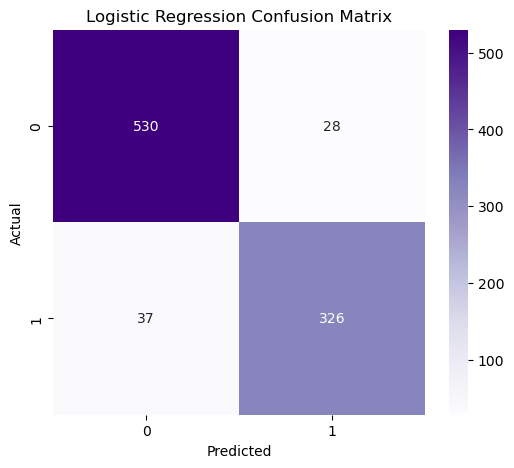

In [44]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [45]:
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000))
])

lr_param_grid = [
    {
        "model__penalty": ["l1"],
        "model__C": [0.01, 0.1, 1, 10, 100],
        "model__solver": ["liblinear", "saga"]
    },
    {
        "model__penalty": ["l2"],
        "model__C": [0.01, 0.1, 1, 10, 100],
        "model__solver": ["liblinear", "saga"]
    }
]

lr_grid = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=lr_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

start_time = time.time()
lr_grid.fit(X_train, y_train)
lr_tuning_time = time.time() - start_time

print("Logistic Regression tuning completed.")
print("Tuning Time:", round(lr_tuning_time, 4), "seconds")
print("\nBest Parameters:")
print(lr_grid.best_params_)
print("\nBest CV Accuracy:", round(lr_grid.best_score_, 4))

best_lr = lr_grid.best_estimator_
y_pred_best_lr = best_lr.predict(X_test)

Logistic Regression tuning completed.
Tuning Time: 15.1834 seconds

Best Parameters:
{'model__C': 1, 'model__penalty': 'l2', 'model__solver': 'saga'}

Best CV Accuracy: 0.9239


In [46]:
# Linear SVM
linear_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="linear"))
])

start_time = time.time()
linear_svm.fit(X_train, y_train)
linear_svm_time = time.time() - start_time
y_pred_linear = linear_svm.predict(X_test)

# Polynomial SVM (degree 3 for the initial kernel comparison)
poly_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="poly", degree=3))
])

start_time = time.time()
poly_svm.fit(X_train, y_train)
poly_svm_time = time.time() - start_time
y_pred_poly = poly_svm.predict(X_test)

# RBF SVM
rbf_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf"))
])

start_time = time.time()
rbf_svm.fit(X_train, y_train)
rbf_svm_time = time.time() - start_time
y_pred_rbf = rbf_svm.predict(X_test)

# Sigmoid SVM
sigmoid_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="sigmoid"))
])

start_time = time.time()
sigmoid_svm.fit(X_train, y_train)
sigmoid_svm_time = time.time() - start_time
y_pred_sigmoid = sigmoid_svm.predict(X_test)

print("SVM kernel models trained successfully.")

SVM kernel models trained successfully.


In [47]:
svm_kernel_results = pd.DataFrame({
    "Kernel": ["Linear", "Polynomial", "RBF", "Sigmoid"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_linear),
        accuracy_score(y_test, y_pred_poly),
        accuracy_score(y_test, y_pred_rbf),
        accuracy_score(y_test, y_pred_sigmoid)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_linear),
        f1_score(y_test, y_pred_poly),
        f1_score(y_test, y_pred_rbf),
        f1_score(y_test, y_pred_sigmoid)
    ],
    "Training Time (s)": [
        linear_svm_time,
        poly_svm_time,
        rbf_svm_time,
        sigmoid_svm_time
    ]
})

display(svm_kernel_results.round(4))

,Kernel,Accuracy,F1 Score,Training Time (s)
0,Linear,0.9294,0.9093,0.1836
1,Polynomial,0.7796,0.6220,0.1434
2,RBF,0.9273,0.9055,0.0783
3,Sigmoid,0.8849,0.8528,0.1057


In [48]:
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC())
])

svm_param_grid = [
    {
        "model__kernel": ["linear"],
        "model__C": [0.1, 1, 10, 100]
    },
    {
        "model__kernel": ["poly"],
        "model__C": [0.1, 1, 10, 100],
        "model__gamma": ["scale", "auto"],
        "model__degree": [2, 3, 4]
    },
    {
        "model__kernel": ["rbf"],
        "model__C": [0.1, 1, 10, 100],
        "model__gamma": ["scale", "auto"]
    },
    {
        "model__kernel": ["sigmoid"],
        "model__C": [0.1, 1, 10, 100],
        "model__gamma": ["scale", "auto"]
    }
]

svm_grid = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

start_time = time.time()
svm_grid.fit(X_train, y_train)
svm_tuning_time = time.time() - start_time

print("SVM tuning completed.")
print("Tuning Time:", round(svm_tuning_time, 4), "seconds")
print("\nBest Parameters:")
print(svm_grid.best_params_)
print("\nBest CV Accuracy:", round(svm_grid.best_score_, 4))

best_svm = svm_grid.best_estimator_
y_pred_best_svm = best_svm.predict(X_test)

SVM tuning completed.
Tuning Time: 11.5171 seconds

Best Parameters:
{'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'rbf'}

Best CV Accuracy: 0.9348


In [49]:
best_lr_accuracy = accuracy_score(y_test, y_pred_best_lr)
best_lr_precision = precision_score(y_test, y_pred_best_lr)
best_lr_recall = recall_score(y_test, y_pred_best_lr)
best_lr_f1 = f1_score(y_test, y_pred_best_lr)

best_svm_accuracy = accuracy_score(y_test, y_pred_best_svm)
best_svm_precision = precision_score(y_test, y_pred_best_svm)
best_svm_recall = recall_score(y_test, y_pred_best_svm)
best_svm_f1 = f1_score(y_test, y_pred_best_svm)

print("Tuned Logistic Regression")
print("----------------------------")
print("Accuracy :", round(best_lr_accuracy, 4))
print("Precision:", round(best_lr_precision, 4))
print("Recall   :", round(best_lr_recall, 4))
print("F1 Score :", round(best_lr_f1, 4))

print("\nBest SVM")
print("----------------------------")
print("Accuracy :", round(best_svm_accuracy, 4))
print("Precision:", round(best_svm_precision, 4))
print("Recall   :", round(best_svm_recall, 4))
print("F1 Score :", round(best_svm_f1, 4))

Tuned Logistic Regression
----------------------------
Accuracy : 0.9305
Precision: 0.9211
Recall   : 0.9008
F1 Score : 0.9109

Best SVM
----------------------------
Accuracy : 0.9207
Precision: 0.9143
Recall   : 0.8815
F1 Score : 0.8976


In [50]:
print("Tuned Logistic Regression Classification Report")
print(classification_report(y_test, y_pred_best_lr))

print("\nBest SVM Classification Report")
print(classification_report(y_test, y_pred_best_svm))

Tuned Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       0.94      0.95      0.94       558
           1       0.92      0.90      0.91       363

    accuracy                           0.93       921
   macro avg       0.93      0.93      0.93       921
weighted avg       0.93      0.93      0.93       921


Best SVM Classification Report
              precision    recall  f1-score   support

           0       0.92      0.95      0.94       558
           1       0.91      0.88      0.90       363

    accuracy                           0.92       921
   macro avg       0.92      0.91      0.92       921
weighted avg       0.92      0.92      0.92       921



In [51]:
model_comparison = pd.DataFrame({
    "Model": [
        "Baseline Logistic Regression",
        "Tuned Logistic Regression",
        "Best SVM"
    ],
    "Accuracy": [
        lr_accuracy,
        best_lr_accuracy,
        best_svm_accuracy
    ],
    "Precision": [
        lr_precision,
        best_lr_precision,
        best_svm_precision
    ],
    "Recall": [
        lr_recall,
        best_lr_recall,
        best_svm_recall
    ],
    "F1 Score": [
        lr_f1,
        best_lr_f1,
        best_svm_f1
    ]
})

display(model_comparison.round(4))

,Model,Accuracy,Precision,Recall,F1 Score
0,Baseline Logistic Regression,0.9294,0.9209,0.8981,0.9093
1,Tuned Logistic Regression,0.9305,0.9211,0.9008,0.9109
2,Best SVM,0.9207,0.9143,0.8815,0.8976


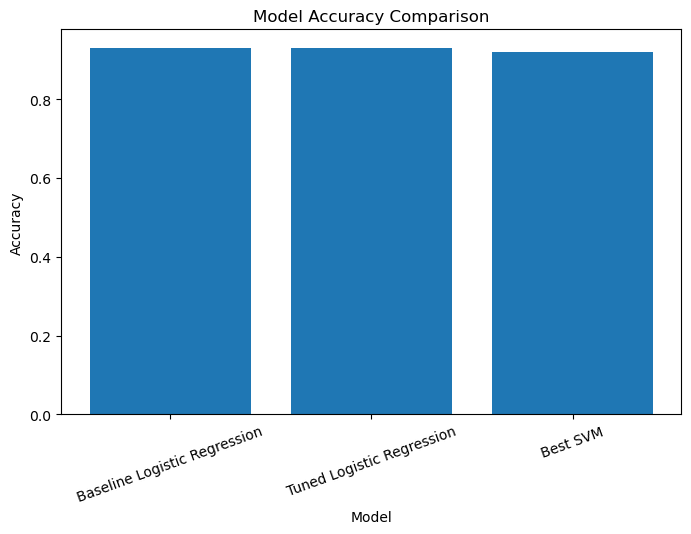

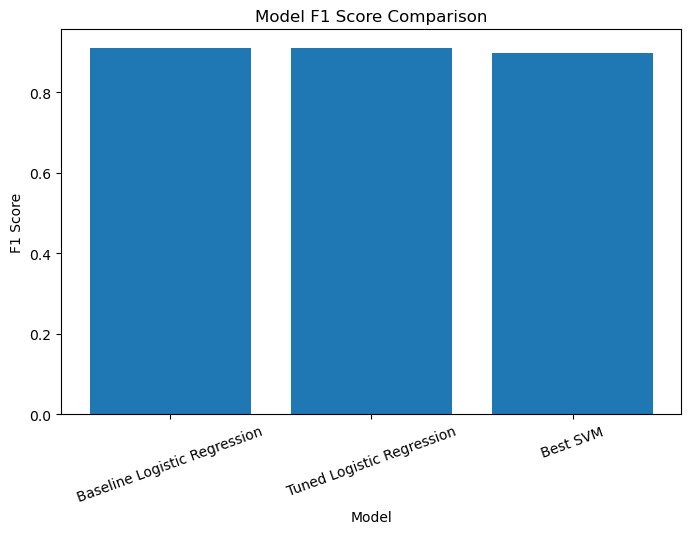

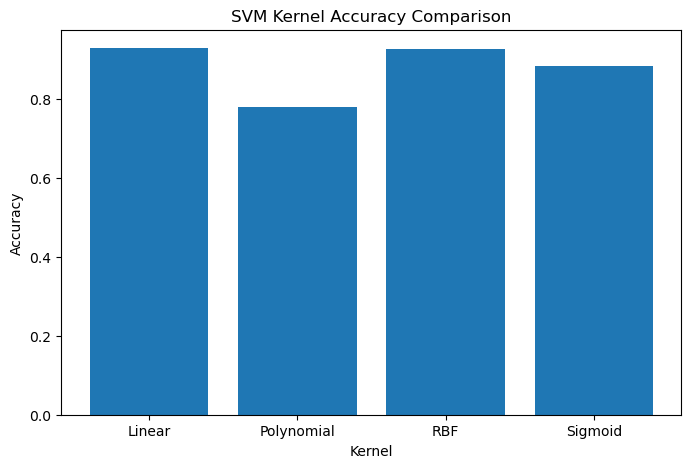

In [52]:
plt.figure(figsize=(8, 5))
plt.bar(model_comparison["Model"], model_comparison["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(model_comparison["Model"], model_comparison["F1 Score"])
plt.title("Model F1 Score Comparison")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.xticks(rotation=20)
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(svm_kernel_results["Kernel"], svm_kernel_results["Accuracy"])
plt.title("SVM Kernel Accuracy Comparison")
plt.xlabel("Kernel")
plt.ylabel("Accuracy")
plt.show()

In [53]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

lr_cv_scores = cross_val_score(
    best_lr,
    X,
    y,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

svm_cv_scores = cross_val_score(
    best_svm,
    X,
    y,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

print("Logistic Regression CV Scores:")
print(np.round(lr_cv_scores, 4))
print("Average:", round(lr_cv_scores.mean(), 4))

print("\nSVM CV Scores:")
print(np.round(svm_cv_scores, 4))
print("Average:", round(svm_cv_scores.mean(), 4))

Logistic Regression CV Scores:
[0.9131 0.9326 0.9283 0.9239 0.9239]
Average: 0.9244

SVM CV Scores:
[0.9305 0.9283 0.9413 0.9326 0.9359]
Average: 0.9337


In [54]:
cv_results = pd.DataFrame({
    "Fold": ["Fold 1", "Fold 2", "Fold 3", "Fold 4", "Fold 5"],
    "Logistic Regression": lr_cv_scores,
    "SVM": svm_cv_scores
})

cv_results.loc[len(cv_results)] = [
    "Average",
    lr_cv_scores.mean(),
    svm_cv_scores.mean()
]

display(cv_results.round(4))

,Fold,Logistic Regression,SVM
0,Fold 1,0.9131,0.9305
1,Fold 2,0.9326,0.9283
2,Fold 3,0.9283,0.9413
3,Fold 4,0.9239,0.9326
4,Fold 5,0.9239,0.9359
5,Average,0.9244,0.9337


In [55]:
logistic_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Training Time (s)"
    ],
    "Value": [
        best_lr_accuracy,
        best_lr_precision,
        best_lr_recall,
        best_lr_f1,
        lr_training_time
    ]
})

display(logistic_results.round(4))

,Metric,Value
0,Accuracy,0.9305
1,Precision,0.9211
2,Recall,0.9008
3,F1 Score,0.9109
4,Training Time (s),0.0134


In [56]:
tuning_results = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM"],
    "Search Method": ["Grid Search", "Grid Search"],
    "Best Parameters": [
        str(lr_grid.best_params_),
        str(svm_grid.best_params_)
    ],
    "Best CV Accuracy": [
        lr_grid.best_score_,
        svm_grid.best_score_
    ]
})

display(tuning_results)

,Model,Search Method,Best Parameters,Best CV Accuracy
0,Logistic Regression,Grid Search,"{'model__C': 1, 'model__penalty': 'l2', 'model...",0.923913
1,SVM,Grid Search,"{'model__C': 10, 'model__gamma': 'scale', 'mod...",0.934783


In [57]:
best_model_row = model_comparison.loc[
    model_comparison["F1 Score"].idxmax()
]

best_kernel_row = svm_kernel_results.loc[
    svm_kernel_results["F1 Score"].idxmax()
]

print("Best Model based on F1 Score:")
print(best_model_row)

print("\nBest SVM Kernel based on F1 Score:")
print(best_kernel_row)

print("\nBest Logistic Regression Parameters:")
print(lr_grid.best_params_)

print("\nBest SVM Parameters:")
print(svm_grid.best_params_)

Best Model based on F1 Score:
Model        Tuned Logistic Regression
Accuracy                       0.93051
Precision                     0.921127
Recall                        0.900826
F1 Score                      0.910864
Name: 1, dtype: object

Best SVM Kernel based on F1 Score:
Kernel                 Linear
Accuracy             0.929425
F1 Score             0.909344
Training Time (s)    0.183584
Name: 0, dtype: object

Best Logistic Regression Parameters:
{'model__C': 1, 'model__penalty': 'l2', 'model__solver': 'saga'}

Best SVM Parameters:
{'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
